In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ROOT

In [19]:
# Asegurarse que AUGEROFFLINEROOT está definido
AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError("AUGEROFFLINEROOT no definido. Hacé 'source this-auger-offline.sh' primero.")

# -----------------------------
# 1️⃣ Cargar librerías Offline
# -----------------------------
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    ROOT.gSystem.Load(os.path.join(AugerOfflineRoot, "lib", lib))


In [20]:
# -----------------------------
# Funciones auxiliares para el MD
# -----------------------------
def getCounterList(sevent, mevent):
    """
    Obtener la lista de counters UMD asociados a las estaciones SD de un evento.

    Parameters
    ----------
    sevent : SDEvent
        Evento reconstruido de superficie.
    mevent : MDEvent
        Evento de muones detectados.

    Returns
    -------
    list of Counter
        Lista de counters (UMD) presentes en el evento.

    Notes
    -----
    Cada Counter representa una estación UMD:
      - Métodos importantes:
        - HasModule(modId) -> bool
        - GetModule(modId) -> Module
        - IsRejected() / IsSaturated() -> bool
      - Contiene módulos (scintillators) donde se detectan muones.
    """
    cList = []
    stationVector = sevent.GetStationVector()
    for station in stationVector:
        stationId = station.GetId()
        counterId = int("10" + str(stationId))
        if mevent.HasCounter(counterId):
            cList.append(mevent.GetCounter(counterId))
    return cList

def getModuleList(counter, sim=True):
    """
    Obtener la lista de módulos (scintillators) de un counter UMD.

    Parameters
    ----------
    counter : Counter
        Counter UMD del que se extraen los módulos.
    sim : bool, default=True
        Indica si es simulación (módulos 0-5) o dato real (100-115).

    Returns
    -------
    list of Module
        Lista de módulos válidos.

    Notes
    -----
    Cada Module contiene información de detección de muones:
      - Métodos importantes:
        - IsRejected() / IsSaturated() -> bool
        - Se puede extraer el número de muones detectados por módulo.
    """
    possibleModules = range(0,6) if sim else range(100,116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules


In [21]:
# -----------------------------
#   Función principal
# -----------------------------
def readADST_to_df(fname):
    """
    Leer archivos ADST y extraer información de MonteCarlo (Mc), SurfaceDetector (SD) y MuonDetector (MD) en un DataFrame.

    Parameters
    ----------
    fname : str or list of str
        Nombre(s) de archivo ADST a procesar.

    Returns
    -------
    pandas.DataFrame
        DataFrame con las siguientes columnas:
          - logE_MC, theta_MC, phi_MC : energía y dirección MC
          - primary : tipo de primario
          - logE_REC, theta_REC, phi_REC : energía y dirección reconstruida SD
          - nModulos : número de módulos UMD válidos en el evento
          - coreUTM_X/Y, coreSite_X/Y : posición del core

    Notas
    -----
    Clases principales involucradas:
      - RecEventFile : lectura de eventos ADST
      - RecEvent : evento individual
      - DetectorGeometry : geometría del detector
      - GenShower : información MC
      - SDEvent / SdRecShower : reconstrucción SD
      - MDEvent : datos UMD (Counters)
      - Counter : estación UMD
      - Module : módulo de scintillator en el counter
      
    """
    # Preparar ADST
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles: 
        files.push_back(datfile)

    # Crear RecEventFile y RecEvent
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        nModulos = 0
        for counter in counterList:
            if counter.IsRejected() or counter.IsSaturated(): continue
            modulesList = getModuleList(counter)
            for mod in modulesList:
                if mod.IsRejected() or mod.IsSaturated(): continue
                nModulos += 1

        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC,
            "primary": primary, "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "nModulos": nModulos,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1]
        })

    df = pd.DataFrame(data)
    return df

In [22]:
# -----------------------------
# Función principal de lectura
# -----------------------------
def readADST_surface(fname):
    """
    Leer archivos ADST y extraer información MC, SD y UMD para mapas de superficie.
    
    Parameters
    ----------
    fname : str or list of str
        Nombre(s) de archivo ADST a procesar.
    
    Returns
    -------
    pandas.DataFrame
        DataFrame por evento con columnas:
          - logE_MC, theta_MC, phi_MC, primary
          - logE_REC, theta_REC, phi_REC
          - coreUTM_X/Y, coreSite_X/Y
          - umdCounters : lista de diccionarios por cada counter con:
                counterId, x, y, nMuones, (opcional: sdId, sdSignal, time)
    """
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles:
        files.push_back(datfile)

    # Inicialización ADST
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        umdCounters = []

        for counter in counterList:
            if counter.IsRejected() or counter.IsSaturated():
                continue

            # Posición del counter (coordenadas de superficie)
            x, y = counter.GetCoreSiteCS()  # o GetCoreUTMCS() si querés UTM
            modulesList = getModuleList(counter)
            nMuones = sum([1 for mod in modulesList if not mod.IsRejected() and not mod.IsSaturated()])

            # Información extra (opcional)
            sdId = counter.GetSdPartnerId()
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            sdSignal = sdStation.GetTotalSignal() if sdStation else None
            # time = ... se podría sacar si quieres los tiempos de trigger

            umdCounters.append({
                "counterId": counter.GetId(),
                "x": x, "y": y,
                "nMuones": nMuones,
                "sdId": sdId,
                "sdSignal": sdSignal
            })

        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
            "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1],
            "umdCounters": umdCounters
        })

    df = pd.DataFrame(data)
    return df


In [43]:
# -----------------------------
# Función principal de lectura para mapas de superficie
# -----------------------------
def readADST_surface(fname):
    """
    Leer archivos ADST y extraer información MC, SD y UMD para mapas de superficie proyectados
    sobre el plano de la lluvia.
    
    Parameters
    ----------
    fname : str or list of str
        Nombre(s) de archivo ADST a procesar.
    
    Returns
    -------
    pandas.DataFrame
        DataFrame por evento con columnas:
          - logE_MC, theta_MC, phi_MC, primary
          - logE_REC, theta_REC, phi_REC
          - coreUTM_X/Y, coreSite_X/Y
          - umdCounters : lista de diccionarios por cada counter con:
                counterId, nMuones, x_plane, y_plane, sdId, sdSignal
    """
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles:
        files.push_back(datfile)

    # Inicialización ADST
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        umdCounters = []

        for counter in counterList:
            print(f"Counter {counter.GetId()} tiene {len(getModuleList(counter))} módulos")

            if counter.IsRejected() or counter.IsSaturated():
                continue

            # Muones válidos en módulos del counter
            modulesList = getModuleList(counter)
            for mod in modulesList:
                print(f"  Módulo {mod.GetId()}, Rejected={mod.IsRejected()}, Saturated={mod.IsSaturated()}")

            nMuones = sum([1 for mod in modulesList if not mod.IsRejected() and not mod.IsSaturated()])

            # Información de SD asociado
            sdId = counter.GetSdPartnerId()
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            sdSignal = sdStation.GetTotalSignal() if sdStation else None

            # Coordenadas del detector en el plano perpendicular al eje de la lluvia
            if sdStation:
                r = sdStation.GetSPDistance()                  # distancia al core en el plano de la lluvia
                phi_rel = sdStation.GetAzimuthSP() - sShower.GetAzimuth()  # diferencia azimutal relativa
                x_plane = r * np.cos(phi_rel)
                y_plane = r * np.sin(phi_rel)
            else:
                x_plane, y_plane = None, None


            umdCounters.append({
                "counterId": counter.GetId(),
                "nMuones": nMuones,
                "x_plane": x_plane,
                "y_plane": y_plane,
                "sdId": sdId,
                "sdSignal": sdSignal
            })

        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
            "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1],
            "umdCounters": umdCounters
        })

    df = pd.DataFrame(data)
    return df


Counter 104004 tiene 3 módulos
  Módulo 1, Rejected=False, Saturated=False
  Módulo 2, Rejected=False, Saturated=False
  Módulo 3, Rejected=False, Saturated=False
Counter 104011 tiene 3 módulos
  Módulo 1, Rejected=False, Saturated=False
  Módulo 2, Rejected=False, Saturated=False
  Módulo 3, Rejected=False, Saturated=False
Counter 104013 tiene 3 módulos
  Módulo 1, Rejected=False, Saturated=False
  Módulo 2, Rejected=False, Saturated=False
  Módulo 3, Rejected=False, Saturated=False
Counter 104001 tiene 3 módulos
  Módulo 1, Rejected=False, Saturated=False
  Módulo 2, Rejected=False, Saturated=False
  Módulo 3, Rejected=False, Saturated=False
Counter 104005 tiene 3 módulos
  Módulo 1, Rejected=False, Saturated=False
  Módulo 2, Rejected=False, Saturated=False
  Módulo 3, Rejected=False, Saturated=False
Counter 104012 tiene 3 módulos
  Módulo 1, Rejected=False, Saturated=False
  Módulo 2, Rejected=False, Saturated=False
  Módulo 3, Rejected=False, Saturated=False
Counter 104003 tiene 3

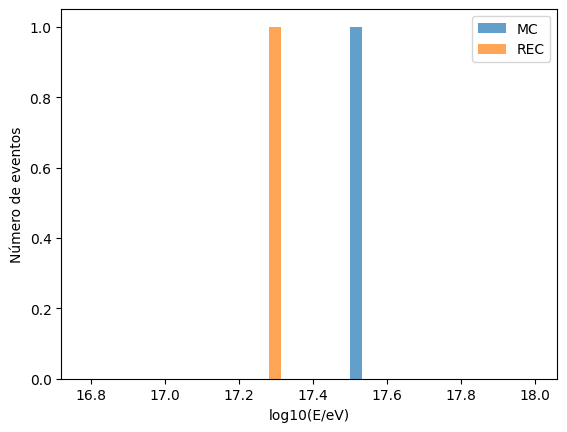

  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root


In [44]:
# -----------------------------
# Ejecutar
# -----------------------------
fname = "/home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root"
df = readADST_surface(fname)
print(df.head())

# Guardar en .npz
np.savez_compressed("ADST_simulation_marina_1.npz", df=df.to_dict("list"))

# -----------------------------
# Plot rápido
# -----------------------------

plt.hist(df["logE_MC"], bins=30, alpha=0.7, label="MC")
plt.hist(df["logE_REC"], bins=30, alpha=0.7, label="REC")
plt.xlabel("log10(E/eV)")
plt.ylabel("Número de eventos")
plt.legend()
plt.show()

In [32]:
# Concatenar todos los counters en un DataFrame
counter_list = []
for _, row in df.iterrows():
    for c in row["umdCounters"]:
        counter_list.append({
            "event": _,
            "counterId": c["counterId"],
            "x_plane": c["x_plane"],
            "y_plane": c["y_plane"],
            "nMuones": c["nMuones"]
        })

df_counters = pd.DataFrame(counter_list)


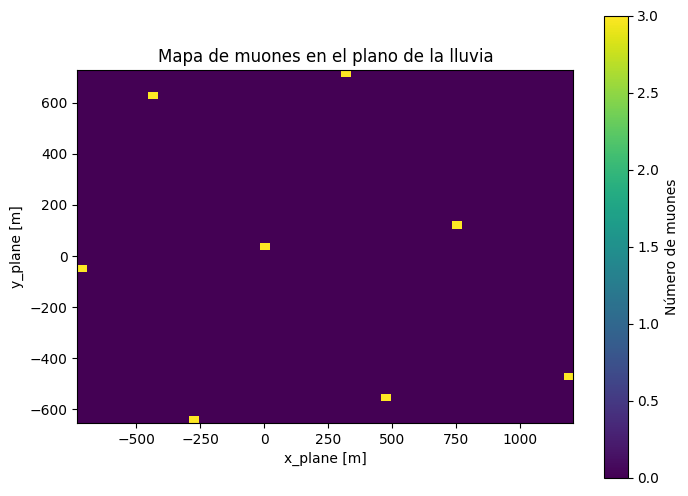

In [33]:
# Bins
xedges = np.linspace(df_counters["x_plane"].min(), df_counters["x_plane"].max(), 50)
yedges = np.linspace(df_counters["y_plane"].min(), df_counters["y_plane"].max(), 50)

# Histograma ponderado por nMuones
H, xedges, yedges = np.histogram2d(
    df_counters["x_plane"], df_counters["y_plane"], 
    bins=[xedges, yedges], 
    weights=df_counters["nMuones"]
)

# Graficar
plt.figure(figsize=(8,6))
plt.imshow(H.T, origin='lower', 
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           cmap="viridis", aspect='equal')
plt.colorbar(label="Número de muones")
plt.xlabel("x_plane [m]")
plt.ylabel("y_plane [m]")
plt.title("Mapa de muones en el plano de la lluvia")
plt.show()


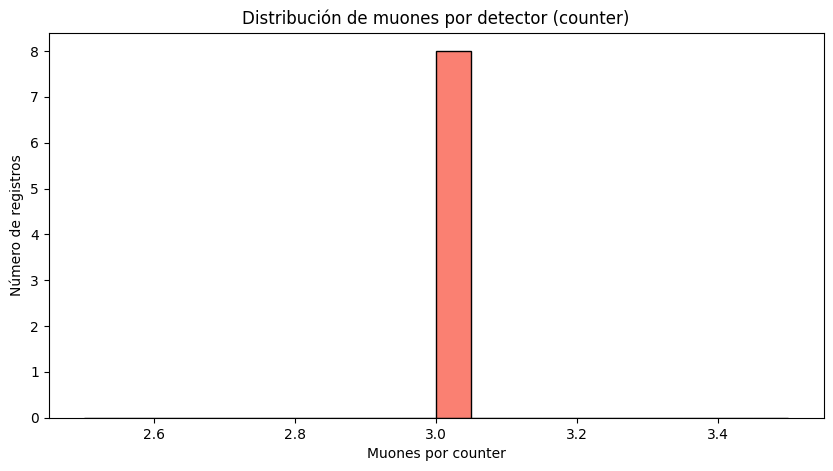

In [35]:
# Crear DataFrame de todos los counters
counter_list = []
for _, row in df.iterrows():
    for c in row["umdCounters"]:
        counter_list.append({
            "event": _,
            "counterId": c["counterId"],
            "nMuones": c["nMuones"]
        })

df_counters = pd.DataFrame(counter_list)

plt.figure(figsize=(10,5))
plt.hist(df_counters["nMuones"], bins=20, color="salmon", edgecolor="k")
plt.xlabel("Muones por counter")
plt.ylabel("Número de registros")
plt.title("Distribución de muones por detector (counter)")
plt.show()


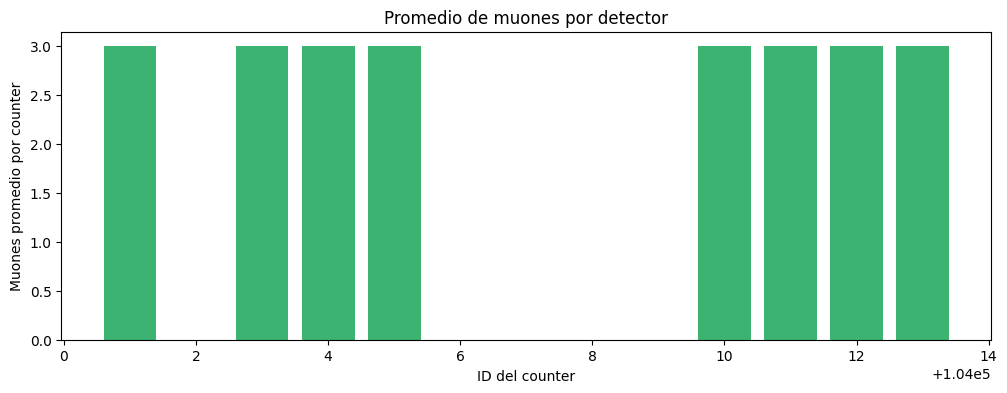

In [36]:
df_avg = df_counters.groupby("counterId")["nMuones"].mean().reset_index()

plt.figure(figsize=(12,4))
plt.bar(df_avg["counterId"], df_avg["nMuones"], color="mediumseagreen")
plt.xlabel("ID del counter")
plt.ylabel("Muones promedio por counter")
plt.title("Promedio de muones por detector")
plt.show()


In [37]:
for _, row in df.iterrows():
    for c in row["umdCounters"]:
        print(f"Counter {c['counterId']}: nMuones={c['nMuones']}, módulos={len(c.get('modules', []))}")


Counter 104004: nMuones=3, módulos=0
Counter 104011: nMuones=3, módulos=0
Counter 104013: nMuones=3, módulos=0
Counter 104001: nMuones=3, módulos=0
Counter 104005: nMuones=3, módulos=0
Counter 104012: nMuones=3, módulos=0
Counter 104003: nMuones=3, módulos=0
Counter 104010: nMuones=3, módulos=0


In [38]:
for counter in counterList:
    print(f"Counter {counter.GetId()} tiene {len(getModuleList(counter))} módulos")


NameError: name 'counterList' is not defined

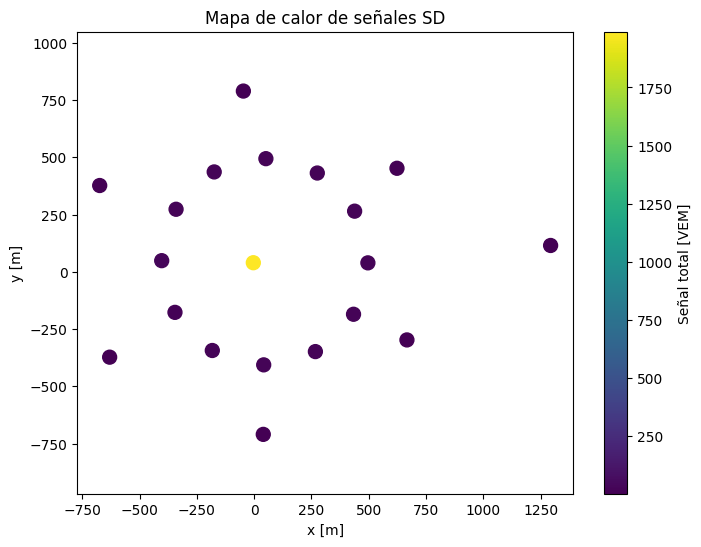

  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root


In [16]:
def readMD_heatmap_event(fname, event_index=0):
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        
        xs, ys, signals = [], [], []
        
        for sdStation in stations:
            r = sdStation.GetSPDistance()
            phi = sdStation.GetAzimuthSP()  # en radianes
            x = r * np.cos(phi)
            y = r * np.sin(phi)
            xs.append(x)
            ys.append(y)
            signals.append(sdStation.GetTotalSignal())
        return np.array(xs), np.array(ys), np.array(signals)

# Ejecutar
fname = "/home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root"
xs, ys, signals = readMD_heatmap_event(fname, event_index=0)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(xs, ys, c=signals, s=100, cmap='viridis')
plt.colorbar(label='Señal total [VEM]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de calor de señales SD')
plt.axis('equal')
plt.show()

Número de estaciones en el evento 0: 20
Estación ID=4004
  --> No tiene UMD, saltando
Estación ID=90010
  --> No tiene UMD, saltando
Estación ID=90008
  --> No tiene UMD, saltando
Estación ID=90009
  --> No tiene UMD, saltando
Estación ID=90006
  --> No tiene UMD, saltando
Estación ID=90005
  --> No tiene UMD, saltando
Estación ID=90001
  --> No tiene UMD, saltando
Estación ID=90000
  --> No tiene UMD, saltando
Estación ID=90002
  --> No tiene UMD, saltando
Estación ID=90004
  --> No tiene UMD, saltando
Estación ID=90007
  --> No tiene UMD, saltando
Estación ID=90003
  --> No tiene UMD, saltando
Estación ID=90011
  --> No tiene UMD, saltando
Estación ID=4011
  --> No tiene UMD, saltando
Estación ID=4013
  --> No tiene UMD, saltando
Estación ID=4001
  --> No tiene UMD, saltando
Estación ID=4005
  --> No tiene UMD, saltando
Estación ID=4012
  --> No tiene UMD, saltando
Estación ID=4003
  --> No tiene UMD, saltando
Estación ID=4010
  --> No tiene UMD, saltando
Fin de lectura de evento.


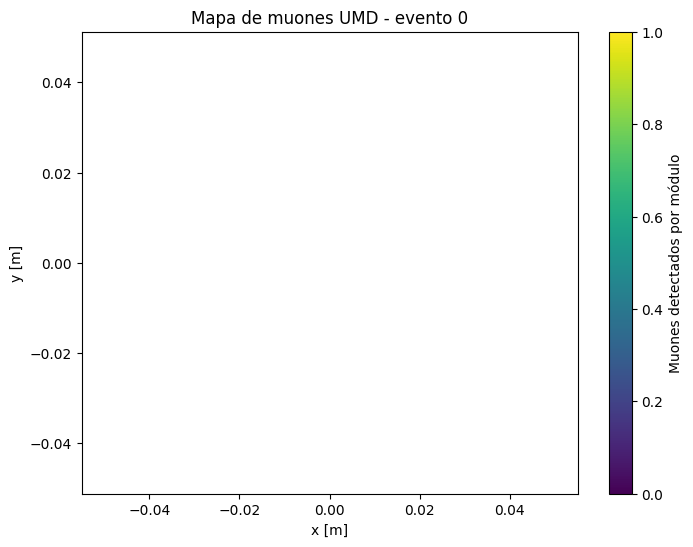

  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root


In [17]:
def readMD_heatmap_event(fname, event_index=0):
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        print(f"Número de estaciones en el evento {event_index}: {stations.size()}")
        
        xs, ys, muon_signals = [], [], []
        station_ids, module_ids = [], []

        for sdStation in stations:
            print(f"Estación ID={sdStation.GetId()}")
            
            if not sdStation.HasScintillator():
                print("  --> No tiene UMD, saltando")
                continue  # solo estaciones UMD
            
            sc = sdStation.GetScintillator()
            n_modules = 3  # típicamente 3 módulos por estación UMD
            pos = sdStation.GetPosition()
            x = pos.X()
            y = pos.Y()
            print(f"  Posición estación: x={x}, y={y}")

            for i in range(n_modules):
                try:
                    muones = sc.GetMuonSignal(i)
                except Exception as e:
                    print(f"    Error al leer módulo {i}: {e}")
                    muones = 0
                print(f"    Módulo {i} detectó {muones} muones")
                
                xs.append(x)
                ys.append(y)
                muon_signals.append(muones)
                station_ids.append(sdStation.GetId())
                module_ids.append(i)
        
        print("Fin de lectura de evento.")
        return {
            'x': np.array(xs),
            'y': np.array(ys),
            'muons': np.array(muon_signals),
            'station_id': np.array(station_ids),
            'module_id': np.array(module_ids)
        }

# Ejecutar
fname = "/home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root"
data = readMD_heatmap_event(fname, event_index=0)

plt.figure(figsize=(8,6))
sc = plt.scatter(data['x'], data['y'], c=data['muons'], s=200, cmap='viridis', edgecolor='k')
plt.colorbar(sc, label='Muones detectados por módulo')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de muones UMD - evento 0')
plt.axis('equal')
plt.show()
